In [1]:
import os
os.chdir("..")

In [2]:
import datetime as dt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearnex import patch_sklearn
patch_sklearn()

import sklearn
from lightgbm import LGBMClassifier

from sklearn.model_selection import TimeSeriesSplit, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import clone
from time import time

from pathlib import Path

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

pd.set_option("display.max_columns", None)

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


# Loading data

In [3]:
data_path = Path("data/merged/merged_preprocessed.csv")

data = pd.read_csv(data_path)
data["time"] = pd.to_datetime(data["time"], utc=True).dt.tz_convert("Europe/Kyiv")
data = data.sort_values(by=["region_id", "time"])

data = data.drop(columns=["year", "month", "day"], errors="ignore")

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 826728 entries, 0 to 826727
Columns: 101 entries, region_id to alarm_status_24h_ago
dtypes: datetime64[us, Europe/Kyiv](1), float64(58), int64(42)
memory usage: 637.1 MB


In [5]:
data.head(3)

,region_id,time,alarm,temp,feelslike,humidity,dew,precip,precipprob,preciptype,windspeed,winddir,pressure,visibility,cloudcover,uvindex,conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,news_count_30d,news_velocity_7d,centroid_shift_30d,dom_cluster_share_30d,centroid_shift_7d,avg_dist_centroid_30d,news_count_7d,avg_dist_centroid_7d,anomaly_count_7d,dom_cluster_share_7d,topic_entropy_30d,news_velocity_30d,topic_entropy_7d,anomaly_count_30d,hour,day_of_week,is_weekend,alarms_count_1h_ago,alarms_count_2h_ago,alarms_count_3h_ago,alarms_count_4h_ago,alarms_count_5h_ago,alarms_count_6h_ago,alarms_count_7h_ago,alarms_count_8h_ago,alarms_count_9h_ago,alarms_count_10h_ago,alarms_count_11h_ago,alarms_count_12h_ago,alarm_status_1h_ago,alarm_status_2h_ago,alarm_status_3h_ago,alarm_status_4h_ago,alarm_status_5h_ago,alarm_status_6h_ago,alarm_status_7h_ago,alarm_status_8h_ago,alarm_status_9h_ago,alarm_status_10h_ago,alarm_status_11h_ago,alarm_status_12h_ago,alarm_status_13h_ago,alarm_status_14h_ago,alarm_status_15h_ago,alarm_status_16h_ago,alarm_status_17h_ago,alarm_status_18h_ago,alarm_status_19h_ago,alarm_status_20h_ago,alarm_status_21h_ago,alarm_status_22h_ago,alarm_status_23h_ago,alarm_status_24h_ago
0,3,2022-03-28 01:00:00+03:00,0,-0.1,-1.8,48.02,-9.8,0.0,0.0,0.0,5.0,291.3,1030.0,24.1,1.6,0.0,0.0,13,5,0,0,4,4,0,0,0,0,0,0,5,5,5,4,0,86,289,-3,13953,0,0,0,0,0,0,0,0,0,1,49,2,0.484262,0.632653,0.179787,0.465249,10,0.386532,1,0.7,0.657529,45,0.610864,5,1,0,0,5.0,10.0,24.0,15.0,3.0,0.0,0.0,3.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3,2022-03-28 02:00:00+03:00,0,-0.6,-0.6,51.39,-9.4,0.0,0.0,0.0,4.7,271.0,1030.0,24.1,2.5,0.0,0.0,8,2,0,0,3,3,0,0,0,0,0,0,1,1,1,4,0,45,285,-3,13953,0,0,0,0,0,0,0,0,0,1,49,2,0.484262,0.632653,0.179787,0.465249,10,0.386532,1,0.7,0.657529,45,0.610864,5,2,0,0,4.0,5.0,10.0,24.0,15.0,3.0,0.0,0.0,3.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2022-03-28 03:00:00+03:00,0,-0.8,-4.5,59.99,-7.6,0.0,0.0,0.0,10.8,270.0,1029.4,10.0,40.0,0.0,4.0,7,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,28,269,-2,13953,0,0,0,0,0,0,0,0,0,1,49,2,0.484262,0.632653,0.179787,0.465249,10,0.386532,1,0.7,0.657529,45,0.610864,5,3,0,0,2.0,4.0,5.0,10.0,24.0,15.0,3.0,0.0,0.0,3.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
data.isna().sum().sum()

np.int64(0)

In [7]:
target = "alarm"

X = data.copy()
y = X.pop(target)

# X = X.drop(columns="other_alarms_count")

In [8]:
cat_cols = list(X.select_dtypes(include=["category", "object"], exclude=["datetime"]).columns)
num_cols = [col for col in X.select_dtypes(include="number").columns if col not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    # ('label_encode', LabelEncoder(), cat_cols),
    ('scale', StandardScaler(), num_cols),
    ("drop_cols", "drop", ["time"]),
], remainder='passthrough')


def evaluate_model(pipeline, X=X, y=y, n_splits: int = 5, gap: int = 24, max_train_size=None):
    
    train_scores = []
    test_scores  = []

    all_y_true = []
    all_y_pred = []
    training_start = time()
    
    unique_hours = X["time"].sort_values().unique()
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap, max_train_size=max_train_size)
    
    for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_hours)):
        train_hours = unique_hours[train_idx]
        test_hours  = unique_hours[test_idx]

        train_mask = X["time"].isin(train_hours) 
        test_mask  = X["time"].isin(test_hours)
               
        X_train = X[train_mask]
        y_train = y[train_mask]
        X_test  = X[test_mask]
        y_test  = y[test_mask]

        # print(f"------------- Fold {fold+1} -------------")
        # print(f'Train dates: {X_train.time.min()} -> {X_train.time.max()}')
        # print(f'Test dates: {X_test.time.min()} -> {X_test.time.max()}')
        
        pipeline.fit(X_train, y_train)

        y_pred_train = pipeline.predict(X_train)
        y_pred_test  = pipeline.predict(X_test)

        train_score = f1_score(y_train, y_pred_train)
        train_scores.append(train_score)

        test_score = f1_score(y_test, y_pred_test)
        test_scores.append(test_score)

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred_test)

        print(f"Fold {fold+1} - train score: {train_score} | test score: {test_score}")

    print("\n------------- Overall -------------")
    print(f"Train F1 : {np.mean(train_scores):.3f} ± {np.std(train_scores):.3f}")
    print(f"Test  F1 : {np.mean(test_scores):.3f} ± {np.std(test_scores):.3f}")
    print(f"Completed in: {time() - training_start:.2f}s.")

    scores = {
        "train_f1": train_scores,
        "test_f1":  test_scores, 
    }
    overall_cm = confusion_matrix(all_y_true, all_y_pred)
    return scores, overall_cm

In [9]:
model = LGBMClassifier(random_state=42, verbose=-1)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

In [10]:
scores, cm = evaluate_model(pipeline, n_splits=10, max_train_size=365*24)

Fold 1 - train score: 0.7314552591046852 | test score: 0.5842624218598956
Fold 2 - train score: 0.6770336976060718 | test score: 0.6332603938730853
Fold 3 - train score: 0.6834688967808454 | test score: 0.6536659108087679
Fold 4 - train score: 0.7239021935159167 | test score: 0.6606197338735669
Fold 5 - train score: 0.7268738574040219 | test score: 0.6809879379666858
Fold 6 - train score: 0.7333827825797369 | test score: 0.7247897906851929
Fold 7 - train score: 0.7448364832613042 | test score: 0.7816846882926178
Fold 8 - train score: 0.774350191853281 | test score: 0.7781721095301664
Fold 9 - train score: 0.7939968104094716 | test score: 0.7606463762833364
Fold 10 - train score: 0.8078673737837725 | test score: 0.8148729905509878

------------- Overall -------------
Train F1 : 0.740 ± 0.041
Test  F1 : 0.707 ± 0.072
Completed in: 84.30s.


In [11]:
# scores, cm = evaluate_model(pipeline, n_splits=30, max_train_size=365*24)

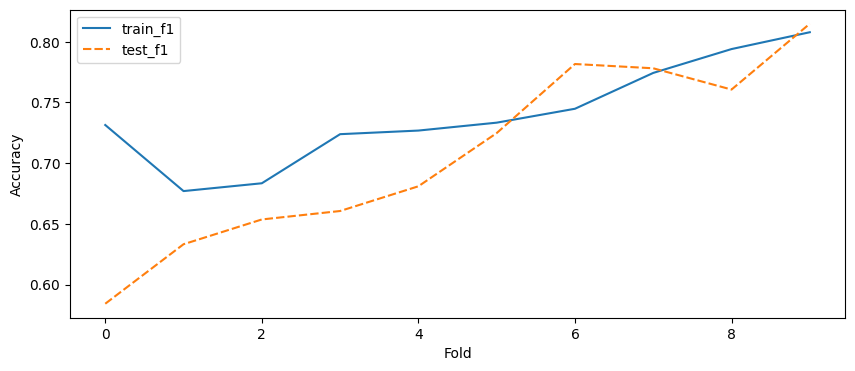

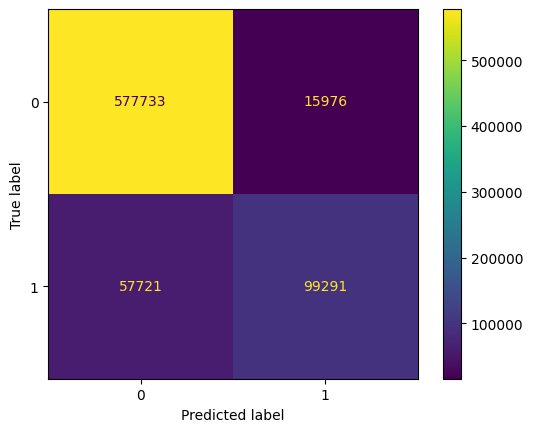

In [12]:
plt.figure(figsize=(10,4))
sns.lineplot(scores)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [13]:
model = LGBMClassifier(random_state=42, verbose=-1)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

In [14]:
mask = X.time >= '2025'
X_from_2025 = X.loc[mask]
y_from_2025 = y.loc[mask]

X_from_2025.shape, y_from_2025.shape

((245114, 100), (245114,))

In [15]:
scores, cm = evaluate_model(pipeline, X=X_from_2025, y=y_from_2025, n_splits=15, gap=24)

Fold 1 - train score: 0.9022281748447583 | test score: 0.7605732261447047
Fold 2 - train score: 0.8736921209318458 | test score: 0.7920537373159926
Fold 3 - train score: 0.8587203637544657 | test score: 0.7589490389701993
Fold 4 - train score: 0.8467622829761396 | test score: 0.7507039920490309
Fold 5 - train score: 0.8329501703459546 | test score: 0.7776087617888652
Fold 6 - train score: 0.8259903132969887 | test score: 0.7622587562544675
Fold 7 - train score: 0.8202949663353639 | test score: 0.7510904332654842
Fold 8 - train score: 0.8145481367005023 | test score: 0.7680631451123254
Fold 9 - train score: 0.8114134958149468 | test score: 0.8007274616783581
Fold 10 - train score: 0.8126492813543224 | test score: 0.8200814111261873
Fold 11 - train score: 0.8142992245129563 | test score: 0.8020820423844343
Fold 12 - train score: 0.8138855277276774 | test score: 0.8192652660031945
Fold 13 - train score: 0.8136432488900496 | test score: 0.8083804143126178
Fold 14 - train score: 0.813027628

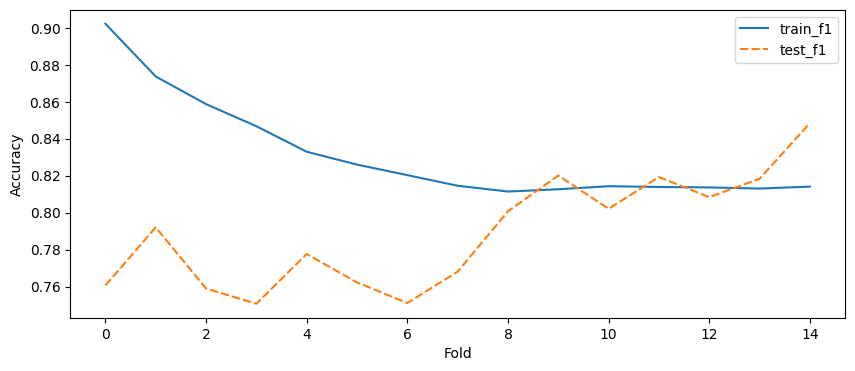

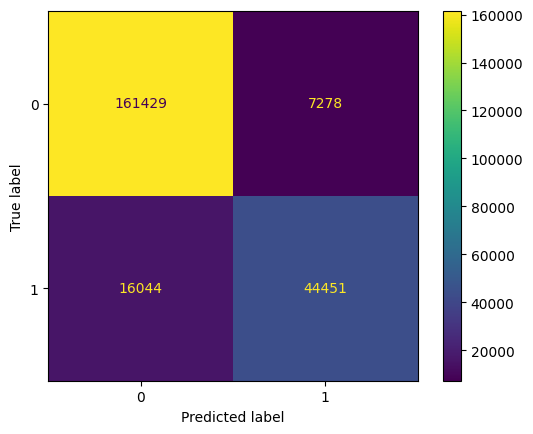

In [16]:
plt.figure(figsize=(10,4))
sns.lineplot(scores)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [20]:
import optuna
from lightgbm import LGBMClassifier


def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 10, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
    }
    model = LGBMClassifier(**params, random_state=42, verbose=-1)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    scores, _ = evaluate_model(pipeline, X=X_from_2025, y=y_from_2025, n_splits=20, gap=24)
    test_score = np.mean(scores["test_f1"])

    return test_score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)
best_params = study.best_params

[I 2026-04-10 13:33:24,290] A new study created in memory with name: no-name-9d49c6ed-36e5-44db-97b6-59c6aa4fa805


Fold 1 - train score: 0.9645950463455402 | test score: 0.7763511495968946
Fold 2 - train score: 0.9367574348756549 | test score: 0.8103233830845771
Fold 3 - train score: 0.9236250501806503 | test score: 0.782574099860752
Fold 4 - train score: 0.9153718747535294 | test score: 0.7691944247578549
Fold 5 - train score: 0.9043191159625362 | test score: 0.751512622574588
Fold 6 - train score: 0.8883506478347146 | test score: 0.7657247037374658
Fold 7 - train score: 0.8814673996814468 | test score: 0.7747002893757751
Fold 8 - train score: 0.8751761443701986 | test score: 0.7673179396092362
Fold 9 - train score: 0.8695118960019622 | test score: 0.7711138310893513
Fold 10 - train score: 0.8612774632761163 | test score: 0.7125869418891632
Fold 11 - train score: 0.8544185655427562 | test score: 0.8044827586206896
Fold 12 - train score: 0.8525615476591961 | test score: 0.8101444170482565
Fold 13 - train score: 0.8534285914407789 | test score: 0.8212824010914052
Fold 14 - train score: 0.84939626499

[I 2026-04-10 13:34:55,060] Trial 0 finished with value: 0.7930222577403556 and parameters: {'n_estimators': 285, 'max_depth': 8, 'num_leaves': 253, 'learning_rate': 0.02684733358096562, 'subsample': 0.7320940008189581, 'colsample_bytree': 0.7878704337489639, 'reg_alpha': 3.5045478758640914e-05, 'reg_lambda': 1.7167673084655206e-06}. Best is trial 0 with value: 0.7930222577403556.


Fold 20 - train score: 0.8425666837039668 | test score: 0.8583937611164318

------------- Overall -------------
Train F1 : 0.875 ± 0.035
Test  F1 : 0.793 ± 0.032
Completed in: 90.71s.
Fold 1 - train score: 0.9950487621905476 | test score: 0.7779420461265524
Fold 2 - train score: 0.956145497213259 | test score: 0.8073623459678677
Fold 3 - train score: 0.9327425698212775 | test score: 0.7836422240128929
Fold 4 - train score: 0.9184865712605371 | test score: 0.7743589743589744
Fold 5 - train score: 0.9042767126960719 | test score: 0.7467667918231122
Fold 6 - train score: 0.8914365120722598 | test score: 0.7637017070979335
Fold 7 - train score: 0.8797752808988764 | test score: 0.7760278175496012
Fold 8 - train score: 0.873902019378792 | test score: 0.7609506973089766
Fold 9 - train score: 0.8641637946856455 | test score: 0.7661813716891773
Fold 10 - train score: 0.858889917079455 | test score: 0.7113101903695409
Fold 11 - train score: 0.8509433329982239 | test score: 0.8008917852855428
Fol

[I 2026-04-10 13:35:42,591] Trial 1 finished with value: 0.7916627235807547 and parameters: {'n_estimators': 111, 'max_depth': 10, 'num_leaves': 84, 'learning_rate': 0.09197932999146106, 'subsample': 0.5972801447766733, 'colsample_bytree': 0.7569181078142391, 'reg_alpha': 0.00016750115645103962, 'reg_lambda': 0.005300677581385072}. Best is trial 0 with value: 0.7930222577403556.


...

Fold 20 - train score: 0.8698853422100654 | test score: 0.8565939344037327

------------- Overall -------------
Train F1 : 0.918 ± 0.041
Test  F1 : 0.793 ± 0.032
Completed in: 138.09s.
Fold 1 - train score: 0.9997006884166417 | test score: 0.7855550601872492
Fold 2 - train score: 0.9955124493341054 | test score: 0.8079862735922633
Fold 3 - train score: 0.9898079184633477 | test score: 0.7874800637958532
Fold 4 - train score: 0.9816393946377814 | test score: 0.7695928453753824
Fold 5 - train score: 0.969335604770017 | test score: 0.7536718422156945
Fold 6 - train score: 0.9610360296814604 | test score: 0.7642427049559981
Fold 7 - train score: 0.9530768466050303 | test score: 0.7777087217733581
Fold 8 - train score: 0.9425724197361735 | test score: 0.7646942410449238
Fold 9 - train score: 0.9358459028137064 | test score: 0.768661971830986
Fold 10 - train score: 0.9258245663918112 | test score: 0.7166778298727394
Fold 11 - train score: 0.9156535329439829 | test score: 0.8065404475043029
F

[I 2026-04-10 14:03:36,493] Trial 13 finished with value: 0.7928837444628904 and parameters: {'n_estimators': 358, 'max_depth': 10, 'num_leaves': 242, 'learning_rate': 0.029428197610698505, 'subsample': 0.5266632522375229, 'colsample_bytree': 0.8543092472690529, 'reg_alpha': 3.62082671807655e-06, 'reg_lambda': 1.7272460714366907e-06}. Best is trial 0 with value: 0.7930222577403556.


Fold 20 - train score: 0.8820922517765453 | test score: 0.8579280021984061

------------- Overall -------------
Train F1 : 0.932 ± 0.039
Test  F1 : 0.793 ± 0.031
Completed in: 135.19s.
Fold 1 - train score: 1.0 | test score: 0.7795546256164998
Fold 2 - train score: 0.9998555748122473 | test score: 0.8039640755651905
Fold 3 - train score: 0.9986342795824797 | test score: 0.781502423263328
Fold 4 - train score: 0.996260969095765 | test score: 0.7700712589073634
Fold 5 - train score: 0.9900012985326581 | test score: 0.7416631490080202
Fold 6 - train score: 0.9839091999219164 | test score: 0.7596717467760844
Fold 7 - train score: 0.9747684445863941 | test score: 0.7747150259067358
Fold 8 - train score: 0.9675491778252715 | test score: 0.7677762458144574
Fold 9 - train score: 0.9617196702002355 | test score: 0.7662522202486679
Fold 10 - train score: 0.9511707795849692 | test score: 0.7166443551985721
Fold 11 - train score: 0.944229367457682 | test score: 0.8012508686587908
Fold 12 - train s

[I 2026-04-10 14:06:06,106] Trial 14 finished with value: 0.7903943744024423 and parameters: {'n_estimators': 478, 'max_depth': 10, 'num_leaves': 190, 'learning_rate': 0.03600191923492079, 'subsample': 0.5112544113373196, 'colsample_bytree': 0.8326664773771716, 'reg_alpha': 7.584178733439698e-06, 'reg_lambda': 2.5948676215622004e-06}. Best is trial 0 with value: 0.7930222577403556.


Fold 20 - train score: 0.8978018792312545 | test score: 0.8562791975817532

------------- Overall -------------
Train F1 : 0.951 ± 0.035
Test  F1 : 0.790 ± 0.032
Completed in: 149.55s.


In [21]:
# best_params_last_year = {'n_estimators': 997,
#  'max_depth': 8,
#  'num_leaves': 106,
#  'learning_rate': 0.17441925591077373,
#  'subsample': 0.9180144644703729,
#  'colsample_bytree': 0.9996511179539831,
#  'reg_alpha': 1.4161883334027732e-05,
#  'reg_lambda': 0.03917170880204555}

best_params

{'n_estimators': 285,
 'max_depth': 8,
 'num_leaves': 253,
 'learning_rate': 0.02684733358096562,
 'subsample': 0.7320940008189581,
 'colsample_bytree': 0.7878704337489639,
 'reg_alpha': 3.5045478758640914e-05,
 'reg_lambda': 1.7167673084655206e-06}

0.8729664243682935
CPU times: total: 53.8 s
Wall time: 6.07 s


[]

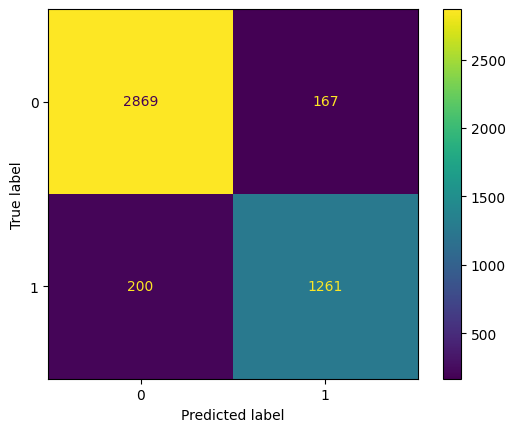

In [23]:
%%time
last_date = data.time.max()
border = last_date - dt.timedelta(days=31)
train_mask = (border >= data.time) & (data.time >= border - dt.timedelta(days=365))
test_mask = data.time >= border

X_train = data[train_mask]
y_train = X_train.pop(target)
X_test = data[test_mask]
y_test = X_test.pop(target)

print(f"{X_train.time.max()=}, {X_test.time.min()}")

model = LGBMClassifier(**best_params, random_state=42, verbose=-1)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

pipeline.fit(X_train, y_train)

y_preds = pipeline.predict(X_test)
score = f1_score(y_test, y_preds)
print(score)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_preds)).plot()
plt.plot()

In [25]:
print(f"{X_train.time.max()=}, {X_test.time.min()}")

X_train.time.max()=Timestamp('2026-03-10 09:00:00+0200', tz='Europe/Kyiv'), 2026-03-10 09:00:00+02:00


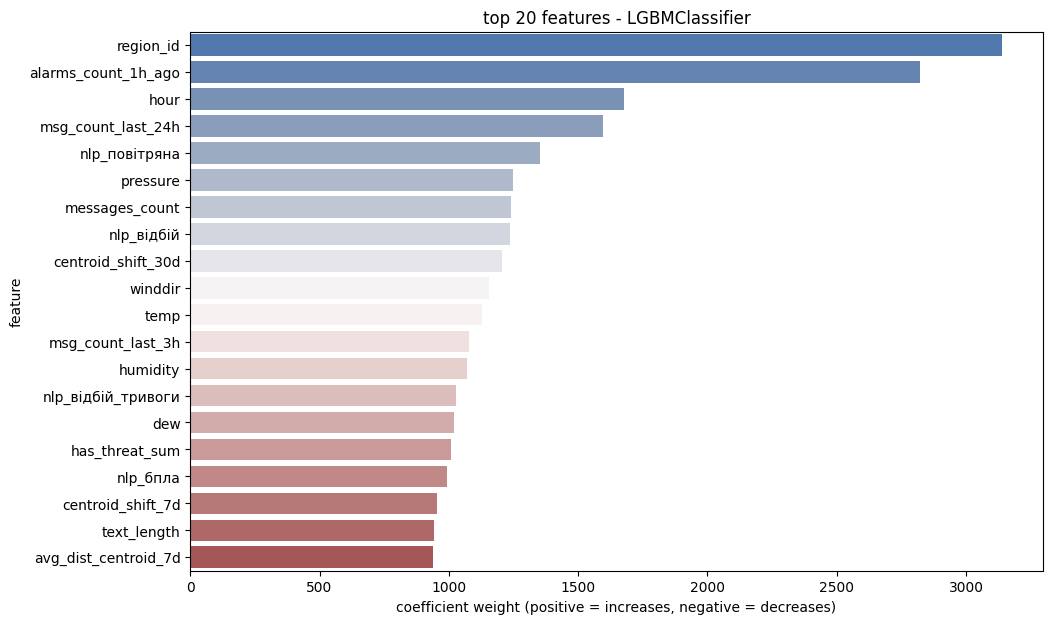

In [24]:
def plot_top_features(pipeline, top_n=20):
    prep_step = pipeline.named_steps["preprocessor"]
    feature_names = prep_step.get_feature_names_out()
    feature_names = [name.split("__")[-1] for name in feature_names]
    model = pipeline.named_steps["model"]
    
    if hasattr(model, "feature_importances_"):
        coefs = model.feature_importances_
    else:
        coefs = model.coef_[0]
    
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Weight": coefs
    })
    
    importance_df["Abs_Weight"] = importance_df["Weight"].abs()
    
    top_20_features = importance_df.sort_values(by="Abs_Weight", ascending=False).head(top_n)
    
    plt.figure(figsize=(11, 7))
    sns.barplot(
        data=top_20_features, 
        x="Weight", 
        y="Feature", 
        hue="Feature", 
        palette="vlag", 
        legend=False
    )
    plt.title("top 20 features - LGBMClassifier")
    plt.xlabel("coefficient weight (positive = increases, negative = decreases)")
    plt.ylabel("feature")
    plt.show()

plot_top_features(pipeline)

In [26]:
import joblib


model_path = Path("app/models/")

joblib.dump(pipeline, model_path / "lgbm_pipeline.joblib")

['app\\models\\lgbm_pipeline.joblib']